# 04 — Multicenter biomarker study with a linear mixed model

This tutorial uses deterministic synthetic data to study a continuous biomarker measured repeatedly within patients enrolled at several centers. The model includes random intercepts for both center and patient.

The data are educational and contain no patient information.

## Objectives

By the end, you will be able to:

- construct a reproducible multicenter longitudinal dataset;
- compile and inspect a Gaussian mixed model before optimization;
- fit a REML random-intercept model through the public API;
- distinguish fixed effects, variance components, convergence, and residual diagnostics;
- state the limits of this dense reference calculation.

In [1]:
import importlib
import logging

import numpy as np

import pymixef

# Keep a fresh-kernel run free of Matplotlib's one-time font-cache status message.
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
plt = importlib.import_module("matplotlib.pyplot")

plt.style.use("tableau-colorblind10")

SEED = 20260704
rng = np.random.default_rng(SEED)

## Create the synthetic study

Six centers enroll six patients each. Every patient has measurements at weeks 0, 4, 8, and 12. Treatment is patient-level; baseline and patient effects stay constant within a patient. Center and patient intercepts create the two clustering levels.

In [2]:
n_centers = 6
patients_per_center = 6
visit_weeks = np.array([0.0, 4.0, 8.0, 12.0])
n_patients = n_centers * patients_per_center

center_index = np.repeat(np.arange(n_centers), patients_per_center * len(visit_weeks))
patient_index = np.repeat(np.arange(n_patients), len(visit_weeks))
week = np.tile(visit_weeks, n_patients)
treatment_by_patient = np.tile(np.array([0, 1, 0, 1, 0, 1]), n_centers)
treatment = np.repeat(treatment_by_patient, len(visit_weeks))
baseline_by_patient = rng.normal(50.0, 7.0, n_patients)
baseline = np.repeat(baseline_by_patient, len(visit_weeks))

center_effect = rng.normal(0.0, 1.2, n_centers)
patient_effect = rng.normal(0.0, 2.0, n_patients)
measurement_error = rng.normal(0.0, 1.0, len(week))

biomarker = (
    8.0
    + 0.12 * baseline
    + 0.15 * week
    + 1.00 * treatment
    + 0.18 * treatment * week
    + center_effect[center_index]
    + patient_effect[patient_index]
    + measurement_error
)

data = {
    "biomarker": biomarker,
    "baseline": baseline,
    "week": week,
    "treatment": treatment,
    "center": np.array([f"C{i + 1}" for i in center_index]),
    "patient": np.array([f"P{i + 1:03d}" for i in patient_index]),
}

{
    "rows": len(biomarker),
    "centers": len(np.unique(data["center"])),
    "patients": len(np.unique(data["patient"])),
    "biomarker_mean": float(np.mean(biomarker)),
}

{'rows': 144,
 'centers': 6,
 'patients': 36,
 'biomarker_mean': 16.165906806474677}

## Observed biomarker trajectories

Start with the raw longitudinal pattern before interpreting a model. Points are arm-specific means; shaded bands are descriptive 95% normal intervals for each mean.

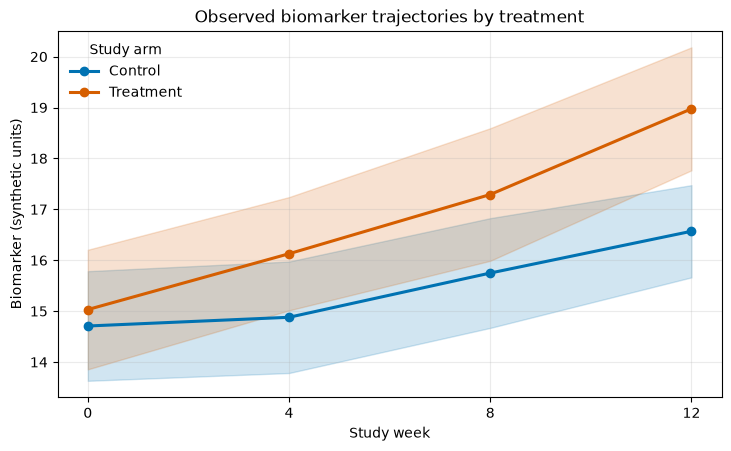

In [3]:
fig, ax = plt.subplots(figsize=(7.2, 4.4), constrained_layout=True)
trajectory_colors = {0: "#0072B2", 1: "#D55E00"}
for arm, label in ((0, "Control"), (1, "Treatment")):
    means = []
    standard_errors = []
    for study_week in visit_weeks:
        values = biomarker[(treatment == arm) & (week == study_week)]
        means.append(float(np.mean(values)))
        standard_errors.append(float(np.std(values, ddof=1) / np.sqrt(len(values))))
    means_array = np.asarray(means)
    interval = 1.96 * np.asarray(standard_errors)
    ax.plot(
        visit_weeks,
        means_array,
        marker="o",
        linewidth=2.2,
        color=trajectory_colors[arm],
        label=label,
    )
    ax.fill_between(
        visit_weeks,
        means_array - interval,
        means_array + interval,
        color=trajectory_colors[arm],
        alpha=0.18,
    )
ax.set(
    title="Observed biomarker trajectories by treatment",
    xlabel="Study week",
    ylabel="Biomarker (synthetic units)",
    xticks=visit_weeks,
)
ax.legend(title="Study arm", frameon=False)
ax.grid(alpha=0.25)
plt.show()

**Interpretation.** Both arms rise over time, with visibly faster growth in the treated arm. These bands summarize raw means; the mixed model below adjusts for baseline and separates center, patient, and residual variation.

## Declare and compile the model

The fixed treatment-by-week interaction asks whether the longitudinal slope differs by treatment. `(1 | center)` and `(1 | patient)` introduce separate Gaussian random intercepts. Compilation checks the formula, constructs the design matrices, audits rows, and selects a compatible engine without fitting yet.

In [4]:
model = pymixef.Model.from_formula(
    "biomarker ~ baseline + treatment * week + (1 | center) + (1 | patient)"
)
plan = model.compile(
    data,
    engine="lmm",
    method="reml",
    maxiter=400,
    compute_hessian=False,
)
print(plan.explain())

Formula: biomarker ~ baseline + treatment * week + (1 | center) + (1 | patient)
Response: biomarker (144 analysis rows)
Fixed design: X(144, 5), rank=5, columns=['Intercept', 'baseline', 'treatment', 'week', 'treatment:week']
Random designs:
  center: Z(144, 1), groups=6, covariance=unstructured
  patient: Z(144, 1), groups=36, covariance=unstructured
Excluded source rows: 0
Family: gaussian (identity link)
Engine: lmm; method: reml
Model IR: ea0b988c07ad2431aeda4f358e0aacaad9b22775c953c28e16398c81f8f1e616
Data audit: 144 input, 144 analysis, 0 excluded; reasons={'DATA-RETAINED-001': 144}


## Fit and inspect the result

A trustworthy analysis must inspect convergence separately from the parameter table. Turning off the optional numerical Hessian keeps this tutorial quick; it also means this notebook does not claim full uncertainty quantification.

In [5]:
fit = plan.fit()
assert fit.convergence.trustworthy, fit.convergence.to_dict()
print(fit.summary())
print("\nConvergence trustworthy:", fit.convergence.trustworthy)
print("Manifest model hash:", fit.manifest.model_ir_hash)

PyMixEF fit (lmm, reml)
Observations: 144
Objective: 262.0969405
Log likelihood: -262.0969405
Convergence: converged
Parameters:
  Intercept               11.697153
  baseline                0.053898225
  treatment               0.61847516
  week                    0.16131562
  treatment:week          0.16352056
  sd(center:Intercept)    1.2846913
  sd(patient:Intercept)   1.884896
  residual_sd             1.0083207

Convergence trustworthy: True
Manifest model hash: sha256:ea0b988c07ad2431aeda4f358e0aacaad9b22775c953c28e16398c81f8f1e616


In [6]:
fixed_names = ["Intercept", "baseline", "treatment", "week", "treatment:week"]
fixed_effects = {name: fit.parameters[name] for name in fixed_names}
variance_components = {
    name: value
    for name, value in fit.parameters.items()
    if name.startswith("sd(") or name == "residual_sd"
}
assert fixed_effects["treatment:week"] > 0, "Expected the generated positive slope difference"
print("Fixed effects:", fixed_effects)
print("Standard-deviation components:", variance_components)
print("Synthetic direction check: positive treatment-by-week estimate")

Fixed effects: {'Intercept': 11.6971534021774, 'baseline': 0.053898224847112666, 'treatment': 0.618475163557215, 'week': 0.16131562308636238, 'treatment:week': 0.16352056061947945}
Standard-deviation components: {'sd(center:Intercept)': 1.2846913472028691, 'sd(patient:Intercept)': 1.8848959702520516, 'residual_sd': 1.0083207473971547}
Synthetic direction check: positive treatment-by-week estimate


## Fixed-effect interval display

A coefficient plot keeps direction, magnitude, and uncertainty visible together. The intercept is omitted so the clinically interesting baseline, treatment, week, and interaction terms share a readable scale.

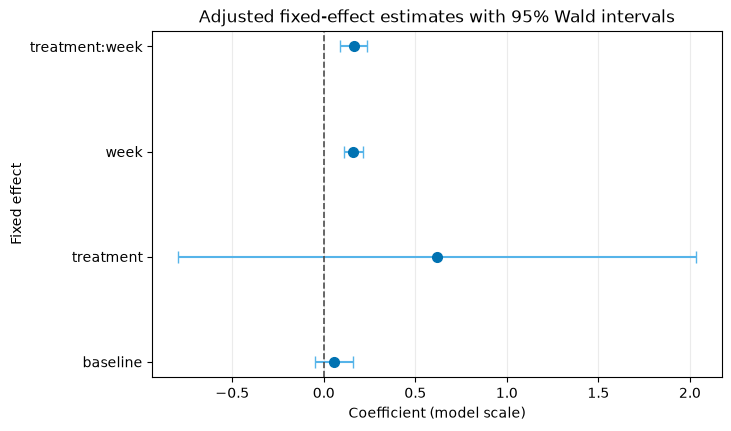

In [7]:
fixed_covariance = np.asarray(fit.extra["fixed_effect_covariance"])
forest_names = fixed_names[1:]
forest_estimates = np.asarray([fit.parameters[name] for name in forest_names])
forest_standard_errors = np.sqrt(np.diag(fixed_covariance))[1:]
forest_positions = np.arange(len(forest_names))

fig, ax = plt.subplots(figsize=(7.2, 4.2), constrained_layout=True)
ax.errorbar(
    forest_estimates,
    forest_positions,
    xerr=1.96 * forest_standard_errors,
    fmt="o",
    color="#0072B2",
    ecolor="#56B4E9",
    capsize=4,
    markersize=7,
)
ax.axvline(0.0, color="#4D4D4D", linestyle="--", linewidth=1.2)
ax.set_yticks(forest_positions, forest_names)
ax.set(
    title="Adjusted fixed-effect estimates with 95% Wald intervals",
    xlabel="Coefficient (model scale)",
    ylabel="Fixed effect",
)
ax.grid(axis="x", alpha=0.25)
plt.show()

**Interpretation.** The positive treatment-by-week estimate supports the generated faster treated-arm slope. The intervals are a compact uncertainty display for this synthetic fit, not a substitute for a prespecified confirmatory inference plan.

### Interpretation

The `treatment:week` coefficient is the estimated difference in weekly slopes for treatment 1 versus treatment 0, conditional on baseline. The center and patient standard deviations summarize unexplained intercept heterogeneity at their respective levels. The residual standard deviation describes remaining within-row variability under this model.

Synthetic truth is useful for checking direction and rough magnitude, but a single simulated dataset is not expected to recover every generating number exactly.

## Residual check

Residual summaries are diagnostics, not proof that the model is correct.

In [8]:
residual_table = fit.residual_diagnostics()
raw = residual_table.columns["raw_residual"]
{
    "rows": len(residual_table),
    "mean_residual": float(np.mean(raw)),
    "residual_rmse": float(np.sqrt(np.mean(raw**2))),
    "largest_absolute_residual": float(np.max(np.abs(raw))),
}

{'rows': 144,
 'mean_residual': -1.603655480014115e-16,
 'residual_rmse': 0.8730843233492872,
 'largest_absolute_residual': 2.6632577080816127}

## Residual pattern by fitted value

Residuals should fluctuate around zero without a strong arm-specific curve or funnel. Plotting them against fitted values can reveal mean-model or variance patterns hidden by scalar summaries.

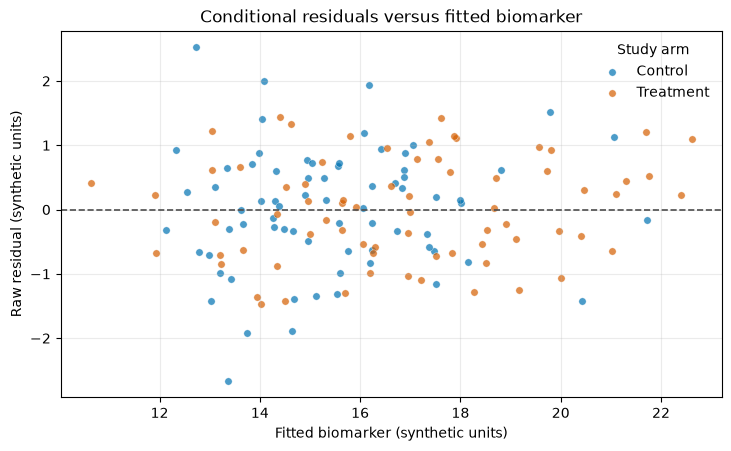

In [9]:
fig, ax = plt.subplots(figsize=(7.2, 4.4), constrained_layout=True)
for arm, label in ((0, "Control"), (1, "Treatment")):
    selected = treatment == arm
    ax.scatter(
        fit.fitted_values[selected],
        raw[selected],
        s=28,
        alpha=0.70,
        color=trajectory_colors[arm],
        edgecolor="white",
        linewidth=0.35,
        label=label,
    )
ax.axhline(0.0, color="#4D4D4D", linestyle="--", linewidth=1.2)
ax.set(
    title="Conditional residuals versus fitted biomarker",
    xlabel="Fitted biomarker (synthetic units)",
    ylabel="Raw residual (synthetic units)",
)
ax.legend(title="Study arm", frameon=False)
ax.grid(alpha=0.25)
plt.show()

**Interpretation.** Residuals are centered near zero across the fitted range, with broadly similar spread by arm. Any reproducible curvature or widening would motivate revisiting the mean or residual-variance model.

## Scope note

This showcase uses PyMixEF's dense experimental LMM reference path for small and moderate problems, with Gaussian independent center and patient effects. It skips Hessian-based uncertainty to keep the run quick; design-specific validation remains essential for causal or regulatory use, and full implementation limitations are tracked in the capability report.

## Exercises

1. Change the random seed and compare sampling variation in the interaction estimate.
2. Add a patient random slope with `(1 + week | patient)` and inspect the larger covariance block.
3. Introduce a few missing biomarker values and inspect the data audit in `plan.explain()`.
4. Refit with `method="ml"` and explain why ML, rather than REML, is normally used for fixed-effect model comparisons.